# Data Collection and Preparation - Health Emergencies Preparedness and Response Program (HEPR)

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities. It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook focuses on a raster-based implementation of market access, using the motorized Global Friction Surface from the [Malaria Atlas Project](https://malariaatlas.org/project-resources/accessibility-to-healthcare/).
Additionaly, it uses population data from [World Pop](https://hub.worldpop.org/project/categories?id=3) (Unconstrained UN-Adjusted 2020, 1km resolution).

## Data Download Links
- [World Pop Raster](https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/2020/)
- [Friction Surface](https://malariaatlas.org/project-resources/accessibility-to-healthcare/)
- [Myanmar Health Facilities](https://data.humdata.org/dataset/hotosm_mmr_health_facilities)
- [Myanmar ACLED conflicts](https://acleddata.com/data-export-tool/)
- [Myanmar SHCC attacks on Healthcare](https://data.humdata.org/dataset/shcchealthcare-dataset?)

# Myanmar - Conflicts disruption

A Healthcare system and Health accessibility disruption is simulated according to ACLED Database of conflicts 

## Setup

Import packages required for the analysis

In [34]:
# System
import sys
import os
from os.path import join, expanduser
from pathlib import Path
# Avoid warnings to pop up
import warnings
warnings.filterwarnings('ignore')

In [89]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

os.environ['CARTOPY_USER_BACKGROUNDS'] = '/home/jupyter-wb618081/Python/Backgrounds/'

In [36]:
# Processing 
import numpy as np
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader

# Raster
import rasterio as rio
from rasterio.features import shapes
from shapely.geometry import box
from rasterio.features import geometry_mask
from rasterstats import zonal_stats
from shapely.geometry import Polygon, box, Point
from shapely.geometry import mapping
import skimage.graph as graph

# Graph
import pickle
import networkx as nx
import osmnx as ox

# for facebook data
# from pyquadkey2 import quadkey

In [37]:
# Parallelization
import multiprocessing
import dask
import dask_geopandas as dask_gpd
import rioxarray as rioxr

In [38]:
# Climate/Flood
# import xarray as xr

In [39]:
# Define your path to the Repositories

sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'health-equity-diagnostics', 'src', 'modules'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'INFRA_SAP'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

from infrasap import aggregator
from infrasap import osm_extractor as osm   

from utils import download_osm_shapefiles

In [40]:
# auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Define below the local folder where you are located

In [41]:
data_dir = join(expanduser("/home/jupyter-wb618081"), 'data')
scratch_dir = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics')
out_path = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics', 'Output')

## Data Preparation

### Administrative boundaries

In [42]:
epsg = "EPSG:4326"
epsg_utm = "EPSG:32647"

In [43]:
country = 'Myanmar'
iso = 'MMR'
downloader = GADMDownloader(version="4.0")
adm0 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=0)
adm1 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=1)
adm2 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=2)

adm1.rename(columns={"NAME_1":"ADM1"}, inplace=True) 
adm2.rename(columns={"NAME_1":"ADM1","NAME_2":"ADM2"}, inplace=True) 

### Population (origin)

In [44]:
# wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above
wp_path = join(data_dir, f'ppp_2020_1km_Aggregated.tif') # Download from link above

pop_surf = rio.open(wp_path)

### Health Facilities (destinations)

In [45]:
hf_path = join(data_dir,iso,'health facilities','hotosm_mmr_health_facilities_points_shp.shp')
geodf_hf = gpd.read_file(hf_path)
geodf_hf = geodf_hf.set_crs(epsg)

# Exclude facilities without geometry
geodf_hf = geodf_hf.loc[~geodf_hf.geometry.isna()]
# For those entries NaN "amenity", assign the corresponding value of "healthcare"
geodf_hf.loc[geodf_hf['amenity'].isna(), 'amenity'] = geodf_hf.loc[geodf_hf['amenity'].isna(), 'healthcare']
# For those entries not classified as hospital but with "Hospital" in its name, classify as hospital 
geodf_hf.loc[(geodf_hf['amenity'] != 'hospital') & (geodf_hf['name_en'].str.contains('Hospital', na=False) | geodf_hf['name'].str.contains('Hospital', na=False)), 'amenity'] = 'hospital'
# Specific case
geodf_hf.loc[(geodf_hf['amenity'] != 'clinic') & (geodf_hf['amenity'] != 'pharmacy') & (geodf_hf['amenity'] != 'hospital') & (geodf_hf['amenity'] != 'dentist') & (geodf_hf['amenity'] != 'doctors'), "amenity"] = "clinic"

display('The following categories and numbers of Health Facilities are considered to perform the analysis: ')
display(geodf_hf["amenity"].value_counts())

# Consider all health facilities and hospitals

geodf_hf_hosp = geodf_hf.loc[geodf_hf['amenity'] == "hospital"]

'The following categories and numbers of Health Facilities are considered to perform the analysis: '

clinic      946
pharmacy    554
hospital    496
dentist     140
doctors     132
Name: amenity, dtype: int64

Assign ADM1 and ADM2 to Health Facilities 

In [46]:
geodf_hf = gpd.sjoin(geodf_hf, adm2[["ADM1", "ADM2", "geometry"]], op='within', how='left'); geodf_hf.drop(columns = "index_right", inplace = True)
geodf_hf_hosp = gpd.sjoin(geodf_hf_hosp, adm2[["ADM1", "ADM2", "geometry"]], op='within', how='left'); geodf_hf_hosp.drop(columns = "index_right", inplace = True)

In [47]:
# Clean the geodf
geodf_hf = geodf_hf[['name_en','amenity', 'osm_id', 'geometry',"ADM1", "ADM2"]]; geodf_hf.rename(columns={'name_en':'Facility Name', 'amenity':'Facility Type'}, inplace = True) 
geodf_hf_hosp = geodf_hf_hosp[['name_en','amenity', 'osm_id', 'geometry',"ADM1", "ADM2"]]; geodf_hf_hosp.rename(columns={'name_en':'Facility Name', 'amenity':'Facility Type'}, inplace = True) 


### Conflicts (ACLED)

Consider conflict events in the period 01/02/2021 - 02/02/2024 as for the following conditions:

EVENT_TYPE:
* Battles
* Violence against civilians
* Riots
* Explosions/Remote violence

FATALITIES
* bigger or equal than 1

<!-- TAGS:
* "armed presence"

TAGS:
* "crowd size">1000  -->

In [48]:
df_acled = pd.read_csv(join(data_dir, iso,'ACLED_Myanmar.csv'))

# Convert pandas df to geodf
gdf_acled = gpd.GeoDataFrame(
    df_acled, geometry=gpd.points_from_xy(df_acled.longitude, df_acled.latitude), crs=epsg
)

gdf_acled.drop(['latitude','longitude'], inplace=True, axis=1)
display('The following categories and numbers of Conflicts are considered to perform the analysis: ')
display(gdf_acled["event_type"].value_counts())

'The following categories and numbers of Conflicts are considered to perform the analysis: '

Battles                       29576
Strategic developments        20352
Explosions/Remote violence    19567
Violence against civilians    13906
Protests                      12278
Riots                           562
Name: event_type, dtype: int64

Assure matching of ADM1 and ADM2 in ACLED 

In [49]:
# The following ADM1 are not corresponding
display(np.setdiff1d(gdf_acled.loc[:,'admin1'].unique(), adm2.ADM1.unique()))

# Manually correct admin1 names in ACLED
gdf_acled.loc[gdf_acled['admin1'] == "Bago-West", 'admin1'] = "Bago"
gdf_acled.loc[gdf_acled['admin1'] == "Bago-East", 'admin1'] = "Bago"
gdf_acled.loc[gdf_acled['admin1'] == "Shan-South", 'admin1'] = "Shan"
gdf_acled.loc[gdf_acled['admin1'] == "Shan-North", 'admin1'] = "Shan"
gdf_acled.loc[gdf_acled['admin1'] == "Shan-East", 'admin1'] = "Shan"
gdf_acled.loc[gdf_acled['admin1'] == "Nay Pyi Taw", 'admin1'] = "Naypyitaw"

# Spatial Join for ADMIN2, since too many incongruencies exists for ADMIN2 names 
gdf_acled = gpd.sjoin(gdf_acled, adm2[["ADM2", "geometry"]], op='within', how='left'); gdf_acled.drop(columns = ["index_right", "admin2"], inplace = True)

array(['Bago-East', 'Bago-West', 'Nay Pyi Taw', 'Shan-East', 'Shan-North',
       'Shan-South'], dtype=object)

In [50]:
# Clean the geodf
gdf_acled = gdf_acled.drop(columns = ["time_precision","inter1", "interaction", "civilian_targeting", "iso", "region", "country", "admin3", "location", "source", "source_scale", "timestamp", "assoc_actor_1"])
gdf_acled.rename(columns = {"admin1":"ADM1", "NAME_2":"ADM2","actor1":"actor" }, inplace = True)

In [51]:
# Restrict the analysis to the period 01/02/2021 - 02/02/2024
gdf_acled["event_date"] = pd.to_datetime(gdf_acled['event_date'], format='%d %B %Y')
gdf_acled = gdf_acled[gdf_acled["event_date"] > pd.Timestamp('2021-02-01')]

Conflicts conditions (as [Davis et al., (2015)](https://link.springer.com/article/10.1186/s13031-015-0059-0))

In [52]:
# Define the conditions for considering events that can disrupt the accessibility to hospitals
cond1 = gdf_acled["event_type"].isin(['Battles', 'Violence against civilians', 'Riots' 'Explosions/Remote violence'])
cond2 = gdf_acled["tags"].str.contains(r'\barmed\b', case=False, na=False)
# cond3 = gdf_acled["tags"].str.extract('crowd size=[^0-9]*([0-9]+)').astype(float)[0]>1000 | gdf_acled["tags"].str.contains(r'\bthousand\b', case=False, na=False) | gdf_acled["tags"].str.contains(r'\bthousands\b', case=False, na=False)

gdf_acled_conflicts = gdf_acled[cond1 | cond2]

Conflicts conditions (as [Ojoloko et al., (2022)](https://onlinelibrary.wiley.com/doi/full/10.1002/wmh3.501))

In [100]:
# Define the conditions for considering events that can disrupt the accessibility to hospitals
cond1 = gdf_acled["event_type"].isin(['Battles', 'Violence against civilians', 'Riots' 'Explosions/Remote violence'])
cond2 = gdf_acled["fatalities"].astype(float)>1

gdf_acled_conflicts_fat = gdf_acled[cond1 & cond2]
gdf_acled_conflicts_fat.drop_duplicates("event_id_cnty", inplace = True)

### Attacks on Health Care (SHCC)

Direct impacts on Health facilities are identified by matching the attacks on "Health Building" in SHCC with the "Explosions/Remote Violence" position of ACLED events happening in the same day and location.

In [53]:
df_shcc_attacks = pd.read_excel(join(data_dir, iso,'SHCC_attacks_health.xlsx'))

In [54]:
# The following ADM1 are not corresponding
display(np.setdiff1d(df_shcc_attacks.loc[:,'Admin 1'].unique(), adm2.ADM1.unique()))

# Manually correct Admin 1 names in ACLED
df_shcc_attacks.loc[df_shcc_attacks['Admin 1'] == "Bago Region", 'Admin 1'] = "Bago"
df_shcc_attacks.loc[df_shcc_attacks['Admin 1'] == "Chin State", 'Admin 1'] = "Chin"
df_shcc_attacks.loc[df_shcc_attacks['Admin 1'] == "Kachin State", 'Admin 1'] = "Kachin"
df_shcc_attacks.loc[df_shcc_attacks['Admin 1'] == "Kayah State", 'Admin 1'] = "Kayah"
df_shcc_attacks.loc[df_shcc_attacks['Admin 1'] == "Sagaing Region", 'Admin 1'] = "Sagaing"
df_shcc_attacks.loc[df_shcc_attacks['Admin 1'] == "Kayin State", 'Admin 1'] = "Kayin"
df_shcc_attacks.loc[df_shcc_attacks['Admin 1'] == "Mon State", 'Admin 1'] = "Mon"
df_shcc_attacks.loc[df_shcc_attacks['Admin 1'] == "Naypyitaw Union Territory", 'Admin 1'] = "Naypyitaw"
df_shcc_attacks.loc[df_shcc_attacks['Admin 1'] == "Shan State", 'Admin 1'] = "Shan"
df_shcc_attacks.loc[df_shcc_attacks['Admin 1'] == "Tanintharyi Region", 'Admin 1'] = "Tanintharyi"

array(['#admin1', 'Bago Region', 'Chin State', 'Kachin State',
       'Kayah State', 'Kayin State', 'Mon State',
       'Naypyitaw Union Territory', 'No Information', 'Sagaing Region',
       'Shan State', 'Tanintharyi Region'], dtype=object)

In [55]:
# Clean the df
df_shcc_attacks = df_shcc_attacks.drop(df_shcc_attacks.index[0])
df_shcc_attacks = df_shcc_attacks[df_shcc_attacks["Admin 1"] != "No Information"]
df_shcc_attacks["Date"] = pd.to_datetime(df_shcc_attacks['Date']) #.strftime('%d %B %Y')
df_shcc_attacks.rename(columns = {"Admin 1":"ADM1", "Date":"event_date", "Location of Incident":"Location"}, inplace = True)


Assign position to SHCC, by defining correspondence between geodf_acled and df_shcc based on event_date, ADM1 and event_type

In [56]:
# Initialize a geometry column in df_shcc if it doesn't exist
if 'geometry' not in df_shcc_attacks.columns:
    df_shcc_attacks['geometry'] = None

# Iterate over df_shcc rows
for index, row in df_shcc_attacks.iterrows():
    # Check if 'Location' is 'Health Building'
    if row['Location'] == 'Health Building':
        # Find matching rows in geodf_acled
        matches = gdf_acled[
            (gdf_acled['event_date'] == row['event_date']) &
            (gdf_acled['ADM1'] == row['ADM1']) &
            (gdf_acled['event_type'] == 'Explosions/Remote violence')
        ]
        # If there are matches, assign the 'geometry' from the first match to df_shcc
        if not matches.empty:
            df_shcc_attacks.at[index, 'geometry'] = matches.iloc[0]['geometry']


In [57]:
# Keep only Health Building damaged and NOT NULL geometries
df_shcc_attacks = df_shcc_attacks[(df_shcc_attacks["Location"] == "Health Building") & (df_shcc_attacks["geometry"].notnull())]
gdf_shcc = gpd.GeoDataFrame(df_shcc_attacks, geometry='geometry')
gdf_shcc = gdf_shcc.set_crs(epsg)

# Assign ADM2 information
gdf_shcc = gpd.sjoin(gdf_shcc, adm2[["ADM2", "geometry"]], op='within', how='left')
gdf_shcc.drop(columns = ["index_right"], inplace = True)
gdf_shcc.rename(columns = {"NAME_2":"ADM2"}, inplace = True)

Consider the HF activity to be disrupted if the following weapons are used:

In [58]:
gdf_shcc = gdf_shcc[gdf_shcc["Weapon Carried/Used"].isin(['Rocket', 'Artillery, Firearms', 'Firearms', 'Aerial Bomb: Drone','Artillery',
                                      'Aerial Bomb: Plane', 'Remote-controlled IED','Mortar','Unspecified IED'])]

### Friction Surface

Process the travel cost surface from the Malaria Atlas Project, clip the raster to our region of interest.

In [59]:
# Only the first time, clip the travel friction surface to the country of interest
out_travel_surface = join(data_dir, iso, f"travel_surface_motorized_{iso}.tif")

if not os.path.isfile(out_travel_surface):
    gfs_path = join(data_dir, '2020_motorized_friction_surface.geotiff')
    gfs_rio = rioxr.open_rasterio(gfs_path, chunks = 500)
    rMisc.clipRaster(gfs_rio, adm0, out_travel_surface, crop=False)

# Import the clipped friction surface
    # rioxarray
# travel_surf = rioxr.open_rasterio(out_travel_surface, chunks = 500) #.read(1)
# travel_surf = travel_surf.isel(band = 0)
    # rasterio
travel_surf = rio.open(out_travel_surface) 

In [60]:
# Only the first time, clip the travel friction surface to the country of interest
out_travel_surface = join(data_dir, iso, f"travel_surface_walking_{iso}.tif")

if not os.path.isfile(out_travel_surface):
    gfs_path = join(data_dir, '2020_walking_only_friction_surface.geotiff')
    gfs_rio = rio.open(gfs_path)
    rMisc.clipRaster(gfs_rio, adm0, out_travel_surface, crop=False)

# Import the clipped friction surface
travel_surf_walk = rio.open(out_travel_surface) #.read(1)

In [61]:
print(travel_surf_walk.res)
print(pop_surf.res)

(0.008333333333333333, 0.008333333333333333)
(0.0083333333, 0.0083333333)


### Preprocessing



Align the POPULATION raster to the friction surface, ensuring that they have the same extent and resolution.

In [62]:
# If the Standardized data are already present, skip, else generate them

def checkDir(out_path):
    if not os.path.exists(out_path):
        os.makedirs(out_path)

out_pop_surface_std = join(data_dir, iso, "WP_2020_1km_STD.tif")
if not os.path.isfile(out_pop_surface_std):
    rMisc.standardizeInputRasters(pop_surf, travel_surf, out_pop_surface_std, resampling_type="nearest")

Align the geometries of Health Facilities and SHCC, ensuring HF correspondence if distance < 200m

In [63]:
from shapely.ops import nearest_points

# Step 1: Find the nearest geometry from gdf_hf for each entry in gdf_shcc
# Create a unary union of gdf_hf geometries for efficient nearest neighbor search
unary_union = geodf_hf.unary_union

# Define a function to find the nearest point in gdf_hf and calculate the distance
def find_nearest(geometry, source_geom_col, target_geom_unary, max_distance):
    # Find the nearest geometry
    nearest_geom = nearest_points(geometry, target_geom_unary)[1]
    
    # Check if the nearest geometry is within the specified distance
    if geometry.distance(nearest_geom) < max_distance:
        return nearest_geom
    else:
        return None

# Apply the function to each geometry in gdf_shcc
gdf_shcc['nearest_geometry'] = gdf_shcc['geometry'].apply(lambda geom: find_nearest(geom, geodf_hf['geometry'], unary_union, 200))

# Step 2: Filter out None values if no geometry within 200 meters was found
gdf_shcc = gdf_shcc.dropna(subset=['nearest_geometry'])

# Step 3: Assign the nearest geometry to the original geometry column (optional based on your requirement)
# This step overwrites the original geometries in gdf_shcc with the matched geometries from gdf_hf if within 200m distance
gdf_shcc['geometry'] = gdf_shcc['nearest_geometry']

# Clean up by removing the temporary 'nearest_geometry' column
gdf_shcc.drop(columns=['nearest_geometry'], inplace=True)

### Origins

Prepare a standard grid (pandas.Dataframe) using each cell from the 1km World Pop raster.

In [64]:
pop_surf = rio.open(out_pop_surface_std)
pop = pop_surf.read(1, masked=False)

In [175]:
# Create a population df from population surface 
indices = list(np.ndindex(pop.shape))
xys = [Point(pop_surf.xy(ind[0], ind[1])) for ind in indices]
res_df = pd.DataFrame({
    'spatial_index': indices,
    'xy': xys,
    'pop': pop.flatten()
})
res_df['pointid'] = res_df.index
res_df

,spatial_index,xy,pop,pointid
0,"(0, 0)",POINT (92.17083333333335 28.545833333333338),3.752286,0
1,"(0, 1)",POINT (92.17916666666669 28.545833333333338),3.951278,1
2,"(0, 2)",POINT (92.18750000000001 28.545833333333338),4.776151,2
3,"(0, 3)",POINT (92.19583333333335 28.545833333333338),2.556102,3
4,"(0, 4)",POINT (92.20416666666668 28.545833333333338),0.882130,4
...,...,...,...,...
2562171,"(2367, 1077)",POINT (101.14583333333336 8.820833333333336),0.000000,2562171
2562172,"(2367, 1078)",POINT (101.15416666666668 8.820833333333336),0.000000,2562172
2562173,"(2367, 1079)",POINT (101.16250000000002 8.820833333333336),0.000000,2562173
2562174,"(2367, 1080)",POINT (101.17083333333335 8.820833333333336),0.000000,2562174


## Conflicts impact on Health facilities

Consider the SHCC dataset

In [66]:
attacks_col = ['Number of Attacks on Health Facilities Reporting Destruction', 'Number of Attacks on Health Facilities Reporting Damaged', 'Forceful Entry into Health Facility',
             'Occupation of Health Facility', 'Health Transportation Destroyed', 'Health Transportation Damaged', 'Health Transportation Stolen/Hijacked', 'Access Denied or Obstructed']

geodf_hf = gpd.sjoin(geodf_hf, gdf_shcc[attacks_col+ ["geometry"]], op='within', how='left')
geodf_hf.drop(columns = {"index_right"}, inplace = True)
# geodf_hf.rename(columns = {attacks_col[0]: "HF Destroyed", attacks_col[1]: "HF Damaged",attacks_col[2]: 'HF Forceful Entry', attacks_col[3]: 'HF Occupation',
#                            attacks_col[-1]: 'HF Not Accessible'})

In [67]:
# If one facilities has been attacked multiple times, consider as only one 
aggregations = {
    'Facility Type': 'first',
    'Facility Name': 'first',
    'ADM1': 'first',
    'ADM2': 'first',
    'geometry': 'first',
    'Number of Attacks on Health Facilities Reporting Destruction': 'max',
    'Number of Attacks on Health Facilities Reporting Damaged': 'max',
    'Forceful Entry into Health Facility': 'max',
    'Occupation of Health Facility': 'max',
    'Health Transportation Destroyed': 'max',
    'Health Transportation Damaged': 'max',
    'Health Transportation Stolen/Hijacked': 'max',
    'Access Denied or Obstructed': 'max',
}

geodf_hf = geodf_hf.groupby("osm_id", as_index=False).agg(aggregations)

### Summary statistics

- Number and % of Health facilities disrupted by Facility Type
- Number and % of Health facilities disrupted by ADM1/ADM2 Districts
- Number and % of Health Facilities affected by type of attack/disruption 

In [68]:
# % of Facilities disrupted, by Facility Type

stats1 = geodf_hf[geodf_hf != 0].groupby("Facility Type").count().drop(columns = ["Facility Name", "ADM1", "ADM2", "geometry"]).rename(columns={'osm_id': 'Total n°'})
attacks_col = [col for col in stats1.columns if col != "Total n°"]
for col in attacks_col:
    stats1[col] = (stats1[col]/stats1["Total n°"])*100

stats1[attacks_col] = stats1[attacks_col].round(2)

stats1['HF Disrupted'] = stats1[attacks_col[1:]].sum(axis = 1)
stats1.rename(columns = {"Number of Attacks on Health Facilities Reporting Destruction": "HF Destroyed", "Number of Attacks on Health Facilities Reporting Damaged": "HF Damaged"}, inplace = True)

display(stats1.head(2))

,Total n°,HF Destroyed,HF Damaged,Forceful Entry into Health Facility,Occupation of Health Facility,Health Transportation Destroyed,Health Transportation Damaged,Health Transportation Stolen/Hijacked,Access Denied or Obstructed,HF Disrupted
Facility Type,,,,,,,,,,
clinic,946,0.21,1.80,1.90,0.85,0.0,0.0,0.0,0.42,4.97
dentist,140,0.00,0.71,2.86,0.71,0.0,0.0,0.0,0.00,4.28


In [69]:
stats1_long = pd.melt(stats1.reset_index().drop(columns = "Total n°"), id_vars="Facility Type", var_name="scen")
scen = stats1_long.scen.unique()

In [70]:
# % of Facilities disrupted, by ADM1 (Districts)

stats2 = geodf_hf[geodf_hf != 0].groupby("ADM1").count().drop(columns = ["Facility Name", "Facility Type", "ADM2", "geometry"]).rename(columns={'osm_id': 'Total n°'})
attacks_col = [col for col in stats2.columns if col != "Total n°"]
for col in attacks_col:
    stats2[col] = (stats2[col]/stats2["Total n°"])*100

stats2[attacks_col] = stats2[attacks_col].round(2)

# stats2['HF Disrupted'] = stats2[attacks_col[1:]].sum(axis = 1)
stats2.rename(columns = {"Number of Attacks on Health Facilities Reporting Destruction": "HF Destroyed", "Number of Attacks on Health Facilities Reporting Damaged": "HF Damaged"}, inplace = True)

# Merge with ADM1 geometries
stats2 = stats2.merge(adm1[["ADM1", "geometry"]], on='ADM1', how='left').set_index("ADM1")
stats2 =gpd.GeoDataFrame(stats2, geometry=stats2["geometry"], crs="EPSG:4326")
display(stats2)

,Total n°,HF Destroyed,HF Damaged,Forceful Entry into Health Facility,Occupation of Health Facility,Health Transportation Destroyed,Health Transportation Damaged,Health Transportation Stolen/Hijacked,Access Denied or Obstructed,geometry
ADM1,,,,,,,,,,
Ayeyarwady,49,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,"MULTIPOLYGON (((94.64847 16.25050, 94.64894 16..."
Bago,140,0.00,4.29,0.71,1.43,0.0,0.00,0.00,0.71,"MULTIPOLYGON (((96.90305 16.80917, 96.90361 16..."
Chin,20,0.00,20.00,10.00,0.00,0.0,0.00,0.00,0.00,"MULTIPOLYGON (((92.66836 21.30609, 92.66812 21..."
Kachin,19,10.53,15.79,10.53,5.26,0.0,0.00,0.00,0.00,"MULTIPOLYGON (((96.95166 23.71944, 96.94721 23..."
Kayah,4,0.00,75.00,25.00,25.00,0.0,0.00,0.00,25.00,"MULTIPOLYGON (((97.35664 18.59554, 97.35526 18..."
Kayin,21,4.76,14.29,19.05,19.05,0.0,0.00,0.00,4.76,"MULTIPOLYGON (((98.58312 16.06054, 98.58199 16..."
Magway,52,0.00,9.62,15.38,5.77,0.0,1.92,0.00,1.92,"MULTIPOLYGON (((95.79526 19.17637, 95.79276 19..."
Mandalay,348,0.29,0.86,3.16,0.86,0.0,0.00,0.00,0.29,"MULTIPOLYGON (((96.37776 19.47137, 96.37303 19..."
Mon,365,0.27,1.10,1.64,0.82,0.0,0.00,0.00,0.27,"MULTIPOLYGON (((97.78555 14.93001, 97.78528 14..."


### Map HF Impact Results

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


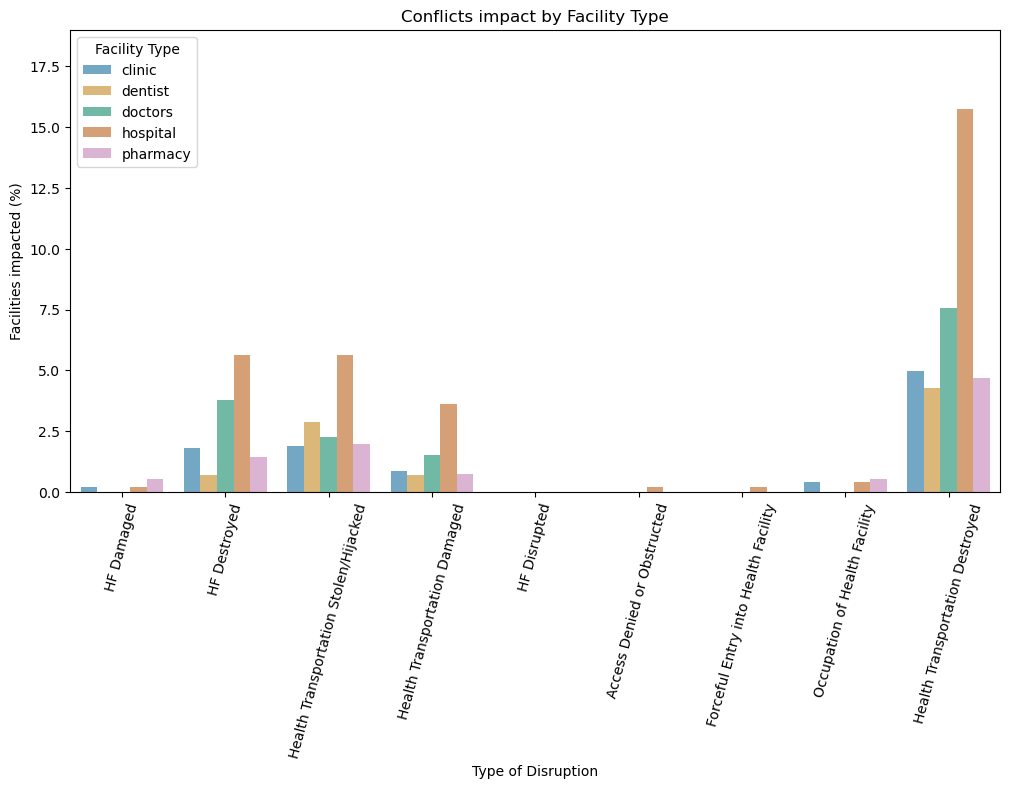

In [41]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Conflicts impact by Facility Type")
ax0.set_xticklabels(list(set(scen)), rotation = 75)
ax0.set_xlabel("Type of Disruption")
ax0.set_ylabel("Facilities impacted (%)")
ax0.set_ylim(0,19)
ax0.legend(loc='upper left', fontsize = 10, title = "Facility type")
ax0 = sns.barplot(
    data=stats1_long, hue="Facility Type",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)

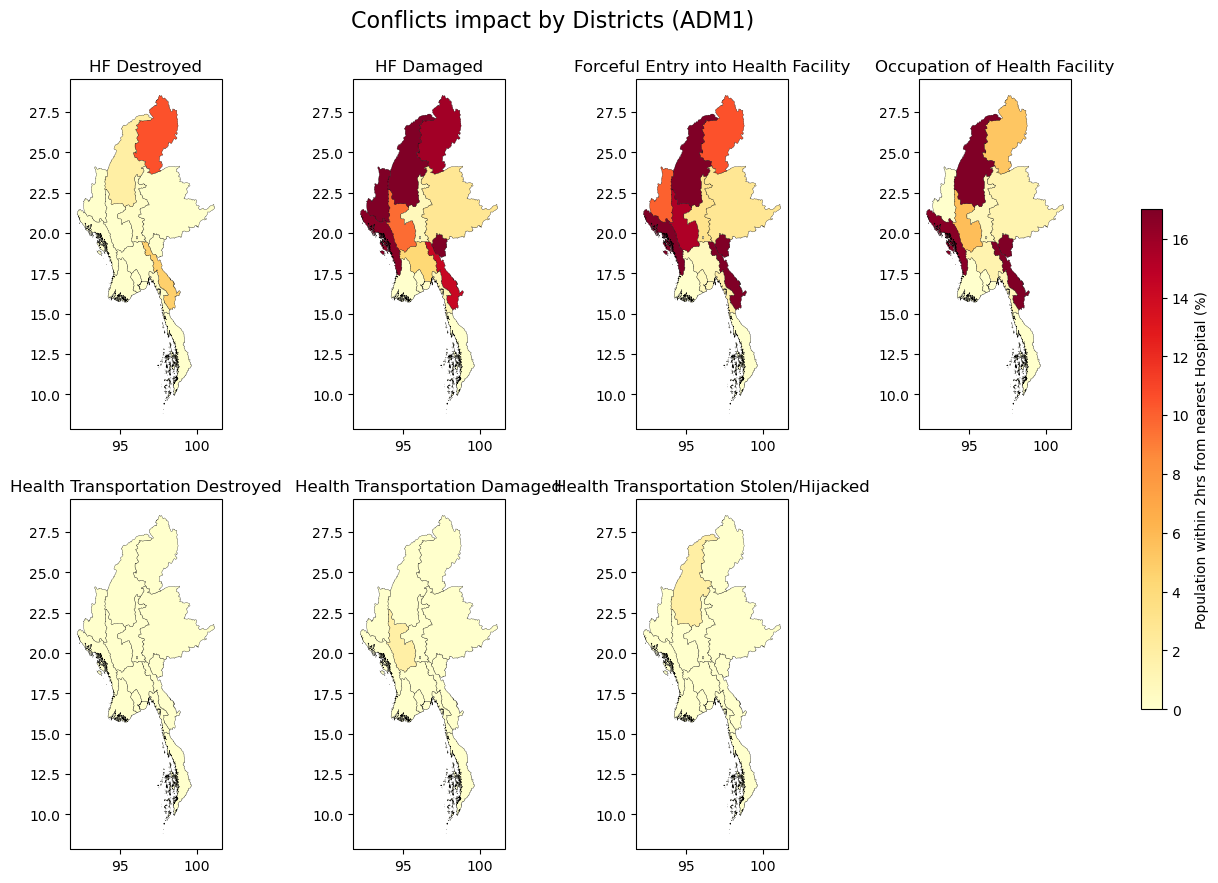

In [43]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (14,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 4)

fig.suptitle("Conflicts impact by Districts (ADM1)", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

# Define the colormap
cmap = plt.get_cmap('YlOrRd')
# Define the normalization 
norm = colors.Normalize(vmin=0, vmax=17)

for i, flood in enumerate(scen[0:-2]):
    if i < 4:
        ax = fig.add_subplot(gs[0,i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1,i-4], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True) # plt.axis('off')
    ax.get_yaxis().set_visible(True)

    stats2.plot(ax=ax, column=flood, cmap='YlOrRd', legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm = norm
    )

cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # Adjust the position and size of the colorbar here
sm = plt.cm.ScalarMappable(cmap=cmap, norm = norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Population within 2hrs from nearest Hospital (%)")

    # ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

## Conflict impact on Friction Surface

Consider the ACLED dataset

We refer to the results obtained by [Davis et al., (2015)](https://link.springer.com/article/10.1186/s13031-015-0059-0). The study found statistical significance of reduction of health outcomes ("a household member was sick and not able to get treatment"), estimating Odds Ratios for both proximity to military base or encounter of army forces. Our assumption is that Odds Ratios estimated for encountering an army force in their study, corresponding to the effect of a health treatment reduction, is directly reflected on the physical accessibility to health facilities. We reduce the OR of 12.5 for every 5-10 km.

We use the Odds Ratio from [Davis et al., (2015)](https://link.springer.com/article/10.1186/s13031-015-0059-0), estimated for Myanmar for the following health services:

- Proximity to Military Base: 1/1.29
- Encounter of army forces: 1/12.5

For every conflict event (as previously defined), within a radius of 5 km, accessibility is impacted by a factor corresponding to 1/12.5. It then decreases by 29% every 5 km.

We consider all conflicts events where the word "armed" is mentioned over time to be representative for generating a 2D disrupted travel surface


In [136]:
# Create 1 hrs isochrones buffers from ACLED conflicts

import geopandas as gpd
import rasterio
from rasterio.features import shapes
import numpy as np
from scipy.signal import convolve


# Function to extract isochrones as polygons
def extract_isochrones(friction_surface, geopd_df, threshold):
    cum_surface = friction_surface.copy()

    affine_transform = friction_surface.transform
    for point in geopd_df.geometry:
        row, col = rio.transform.rowcol(affine_transform, point.x, point.y)

    # Create a kernel to look at all neighboring cells
    kernel = np.ones((3, 3))
    neighbor_sum = convolve(cum_surface, kernel, mode='same', boundary='fill', fillvalue=0)
    
    mask = cumulative_surface <= threshold
    transform = rasterio.transform.from_origin(west, north, cell_size, cell_size)  # Define as per your raster's georeferencing
    polygons = [geom for geom, val in shapes(cumulative_surface, mask=mask, transform=transform) if val]
    return polygons

# Read the raster
with rasterio.open('path_to_your_raster.tif') as src:
    friction_surface = src.read(1)  # Assuming the friction values are in the first band
    affine = src.transform

# Load your points from GeoDataFrame
points_geodf = gpd.read_file('path_to_your_points.geojson')

# Convert your points to a raster-like array where the start points are marked, you may need a specific function for this
start_points = convert_points_to_raster_array(points_geodf, friction_surface.shape, affine)

# Compute the cumulative travel time from each start point
cumulative_travel_time_surface = compute_cumulative_travel_time(friction_surface, start_points)

# Extract the 1-hour isochrone polygons
isochrone_polygons = extract_isochrones(cumulative_travel_time_surface, threshold=1.0)

# Convert the isochrone polygons to a GeoDataFrame
isochrones_geodf = gpd.GeoDataFrame(geometry=gpd.GeoSeries(isochrone_polygons), crs=points_geodf.crs)

# Now, you can use isochrones_geodf as needed, e.g., saving to a file or plotting.


Create new Friction Surface that accounts for Conflicts disruption 

### Mask of buffer zones

Davis et al., 2015

In [96]:
%%time

# Create 5 km buffer zones from points of conflicts (8 buffers from 5 to 40 km)

gdf_acled_conflicts_buffer = gdf_acled_conflicts.copy().to_crs(epsg_utm)

for n in np.arange(5,41,5): 
    if n == 5:
        gdf_acled_conflicts_buffer['geometry_'+str(n)] = gdf_acled_conflicts_buffer['geometry'].apply(lambda x: x.buffer(n*1000))
    else:
        gdf_acled_conflicts_buffer['geometry_'+str(n)] = gdf_acled_conflicts_buffer['geometry'].apply(lambda x: x.buffer(n*1000)) - gdf_acled_conflicts_buffer['geometry'].apply(lambda x: x.buffer((n-5)*1000))
    # Every geometry must be converted back to epsg
    gdf_acled_conflicts_buffer['geometry_'+str(n)] = gdf_acled_conflicts_buffer['geometry_'+str(n)].to_crs(epsg)

gdf_acled_conflicts_buffer = gdf_acled_conflicts_buffer.to_crs(epsg)

CPU times: user 2min 13s, sys: 782 ms, total: 2min 13s
Wall time: 2min 14s


Ojojoko et al., 2022

In [207]:
%%time

# Create 5 km buffer zones from points of conflicts (8 buffers from 5 to 40 km)

gdf_acled_conflicts_buffer_fat = gdf_acled_conflicts_fat.copy().to_crs(epsg_utm)

for n in np.arange(5,41,5): 
    if n == 5:
        gdf_acled_conflicts_buffer_fat['geometry_'+str(n)] = gdf_acled_conflicts_buffer_fat['geometry'].apply(lambda x: x.buffer(n*1000))
    else:
        gdf_acled_conflicts_buffer_fat['geometry_'+str(n)] = gdf_acled_conflicts_buffer_fat['geometry'].apply(lambda x: x.buffer(n*1000)) - gdf_acled_conflicts_buffer_fat['geometry'].apply(lambda x: x.buffer((n-5)*1000))
    # Every geometry must be converted back to epsg
    gdf_acled_conflicts_buffer['geometry_'+str(n)] = gdf_acled_conflicts_buffer['geometry_'+str(n)].to_crs(epsg)

gdf_acled_conflicts_buffer_fat = gdf_acled_conflicts_buffer.to_crs(epsg)

CPU times: user 6.56 s, sys: 107 ms, total: 6.67 s
Wall time: 6.66 s


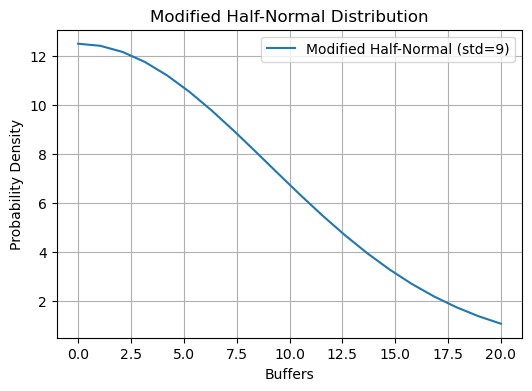

[12.5        12.41479533 12.16265022 11.75373711 11.20425103 10.53534569
  9.77178386  8.94042196  8.06865754  7.18296337  6.30761421  5.46368554
  4.66837109  3.93463226  3.27116182  2.68261908  2.17007675  1.73161078
  1.36296458  1.05822486]


In [613]:
# Generate half-normal distribution weights (from Davis et al., (2015))

from scipy.stats import halfnorm

# Define the range of values according to n° of buffers
x = np.linspace(0, 20, 20)  # Adjust the range based on your requirement

# Define the standard deviation (adjust to obtain 1 in the last part of the PDF)
std_dev = 9

# Calculate the probability density function (PDF) for the given standard deviation
pdf = halfnorm.pdf(x, scale=std_dev)

# Scale the PDF to have a value of 12.5 at x = 0 
pdf_scaled = pdf * 12.5 / pdf[0]

# Plot the modified half-normal distribution
plt.figure(figsize=(6, 4))
plt.plot(x, pdf_scaled, label='Modified Half-Normal (std=' + str(std_dev) + ')')
plt.title('Modified Half-Normal Distribution')
plt.xlabel('Buffers')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()
print(pdf_scaled)

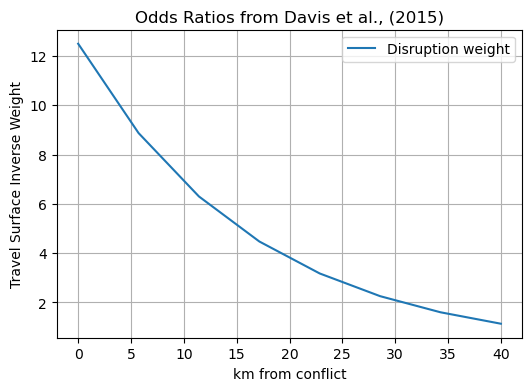

[12.5         8.875       6.30125     4.4738875   3.17646012  2.25528669
  1.60125355  1.13689002]


In [94]:
# Define the initial value and the decrease rate (from Davis et al., 2015)
initial_value = 12.5
decrease_rate = 0.29

# Define the number of steps
num_steps = 8  # Adjust the number of steps as needed
x = np.linspace(0,8,8)
# Initialize an empty array to store the values
pdf = np.zeros(num_steps)

# Calculate the values for each step
current_value = initial_value
for i in range(num_steps):
    pdf[i] = current_value
    current_value *= (1 - decrease_rate)

# Plot the modified half-normal distribution
plt.figure(figsize=(6, 4))
plt.plot(x*5, pdf, label='Disruption weight')
plt.title('Odds Ratios from Davis et al., (2015)')
plt.xlabel('km from conflict')
plt.ylabel('Travel Surface Inverse Weight')
plt.legend()
plt.grid(True)
plt.show()
print(pdf)


In [202]:
%%time

initial_weight = 1.0
conflicts_weight = np.full((travel_surf.height, travel_surf.width), initial_weight)
i = 0
for geom in [col for col in gdf_acled_conflicts_buffer.columns if col.startswith("geometry_")]:
    # Generate a mask for geometries in the GeoDataFrame (True inside geometries, False outside)
    geom_mask = geometry_mask([mapping(geometry) for geometry in gdf_acled_conflicts_buffer[geom]], 
                              invert=True, transform=travel_surf.transform, 
                              all_touched=True, out_shape=(travel_surf.height, travel_surf.width))
    
    conflicts_weight[geom_mask] = pdf[i]
                
    i = i+1

CPU times: user 4min 29s, sys: 4.9 s, total: 4min 34s
Wall time: 4min 33s


In [208]:
%%time

initial_weight = 1.0
conflicts_weight_fat = np.full((travel_surf.height, travel_surf.width), initial_weight)
i = 0
for geom in [col for col in gdf_acled_conflicts_buffer_fat.columns if col.startswith("geometry_")]:
    # Generate a mask for geometries in the GeoDataFrame (True inside geometries, False outside)
    geom_mask_fat = geometry_mask([mapping(geometry) for geometry in gdf_acled_conflicts_buffer_fat[geom]], 
                              invert=True, transform=travel_surf.transform, 
                              all_touched=True, out_shape=(travel_surf.height, travel_surf.width))
    
    conflicts_weight_fat[geom_mask_fat] = 1 / 0.71
                
    i = i+1

CPU times: user 4min 34s, sys: 5.79 s, total: 4min 40s
Wall time: 4min 39s


In [210]:
np.unique(conflicts_weight_fat)

array([1.4084507])

In [172]:
output_raster_path = join(out_path, iso, 'travel_surf_conflict_Davis&Ojoloko.tif')

# Weight the Friction Surface with the conflicts weight
travel_surf_conflict = travel_surf.read(1) * conflicts_weight

# Write the modified raster data to a new file using the metadata from the original raster
with rio.open(output_raster_path, 'w', **travel_surf.meta) as dst:
    dst.write(travel_surf_conflict, 1)

Create an MCP graph object from the conflict friction surfaces.

In [173]:
# convert friction surface to traversal time (lazily). Original data are minutes to travel 1 m:
# We convert it to minutes to cross the cell (1000m). This could be revised

inG_data = dict()
inG_data["baseline"] = travel_surf.read(1) * 1000
inG_data["conflict"] = travel_surf_conflict * 1000

# Correct no data values. Not needed but good to check
# inG_data[inG_data < 0] = 99999999
# inG_data[inG_data < 0] = np.nan

mcp = dict()
mcp["baseline"] = graph.MCP_Geometric(inG_data["baseline"])
mcp["conflict"] = graph.MCP_Geometric(inG_data["conflict"])

# Check descriptive statistics
print(f"Mean: {np.mean(inG_data['conflict'])}")
print(f"Max: {np.max(inG_data['conflict'])}")
print(f"Min: {np.min(inG_data['conflict'])}")
print(f"Std: {np.std(inG_data['conflict'])}")

Mean: 413.465998468512
Max: 678984.2122037646
Min: 8.80281731951982
Std: 744.9821276272568


## Data analysis

**Indicators of interest**

Percentage of population within 2h of driving to the nearest primary care facility (population level, and by SES quintile). \
Percentage of population within 2h of driving to the nearest district hospital (population, and by SES quintile). \
Percentage of health facilities with direct access to an all season road. \
Percentage of health facilities within 2km of an all season road.


In [176]:
# Calculate the travel time from each grid-cell to the nearest destination
res_hf = dict()
res_hf_hosp = dict()
res_hf["baseline"] = ma.calculate_travel_time(travel_surf, mcp["baseline"], geodf_hf)[0]
res_hf_hosp["baseline"] = ma.calculate_travel_time(travel_surf, mcp["baseline"], geodf_hf_hosp)[0]

res_hf["conflict"] = ma.calculate_travel_time(travel_surf, mcp["conflict"], geodf_hf)[0]
res_hf_hosp["conflict"] = ma.calculate_travel_time(travel_surf, mcp["conflict"], geodf_hf_hosp)[0]

# Check dimension
display(len(res_hf["conflict"].flatten()), len(geodf_hf_hosp))

# Decide to consider all facilities or Hospitals
res_df.loc[:, 'tt_hf_' + "baseline"] = res_hf["baseline"].flatten()
res_df.loc[:, 'tt_hosp_' + "baseline"] = res_hf_hosp["baseline"].flatten()

res_df.loc[:, 'tt_hf_' + "conflict"] = res_hf["conflict"].flatten()
res_df.loc[:, 'tt_hosp_' + "conflict"] = res_hf_hosp["conflict"].flatten()

# remove values where pop is 0 or nan
res_df = res_df.loc[res_df['pop']!=0].copy()
res_df = res_df.loc[~(res_df['pop'].isna())].copy()

res_df.loc[:,'xy'] = res_df.loc[:,'xy'].apply(lambda x: Point(x))

res_df.head(2)

2562176

496

,spatial_index,xy,pop,pointid,tt_hf_baseline,tt_hosp_baseline,tt_hf_conflict,tt_hosp_conflict
0,"(0, 0)",POINT (92.17083333333335 28.545833333333338),3.752286,0,1981.057733,1981.057733,34877.777123,34877.777123
1,"(0, 1)",POINT (92.17916666666669 28.545833333333338),3.951278,1,1947.946102,1947.946102,34294.825874,34294.825874


Create Geodataframe for the population grid

In [177]:
res_gdf = gpd.GeoDataFrame(res_df, geometry='xy', crs=epsg)
res_gdf.rename(columns={'xy':'geometry'}, inplace=True)
res_gdf.set_geometry('geometry', inplace=True)

# convert travel time from minutes to hours
for col in res_gdf.columns:
    if 'tt_' in col:
        res_gdf.loc[:, col] = res_gdf.loc[:, col] / 60
        
res_gdf.head(2)

,spatial_index,geometry,pop,pointid,tt_hf_baseline,tt_hosp_baseline,tt_hf_conflict,tt_hosp_conflict
0,"(0, 0)",POINT (92.17083 28.54583),3.752286,0,33.017629,33.017629,581.296285,581.296285
1,"(0, 1)",POINT (92.17917 28.54583),3.951278,1,32.465768,32.465768,571.580431,571.580431


Save results as raster

In [178]:
# Checking if files are already saved in the folder

for col in res_gdf.columns:

    # Health facilities Travel Time surfaces
    if "tt_hf_baseline" in col:
        file = join(out_path, iso, "tt_hf_min_motorized_friction_" + col.split('_')[2] + ".tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
    
    if 'tt_hf_conflict' in col:
        file = join(out_path, iso, "tt_hf_min_motorized_friction_" + col.split('_')[2] + "_Davis&Ojoloko.tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
        else:
            print(file.split('/')[6] + " already present")
    
    # Hospitals Travel Time surfaces 
    if "tt_hosp_baseline" in col:
        file = join(out_path, iso, "tt_hospitals_min_motorized_friction_" + col.split('_')[2] + ".tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
                        
    if 'tt_hosp_conflict' in col:
        file = join(out_path, iso, "tt_hospitals_min_motorized_friction_" + col.split('_')[2] + "_Davis&Ojoloko.tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
        else:
            print(file.split('/')[6] + " already present")


Saving /home/jupyter-wb618081/Health-Access-Metrics/Output/MMR/tt_hf_min_motorized_friction_conflict_Davis&Ojoloko.tif
Saving /home/jupyter-wb618081/Health-Access-Metrics/Output/MMR/tt_hospitals_min_motorized_friction_conflict_Davis&Ojoloko.tif


### Map Travel Time Results

In [179]:
# Baseline and Conflict scenarios
conflict_path = join(out_path, iso)
files=os.listdir(conflict_path)

tt_rio_hf = {}
tt_rio_hosp = {}
for file in files:
    if 'tt_hf' in file and 'baseline' in file:
        value = rio.open(join(conflict_path,file)) #.read(1)
        tt_rio_hf["baseline"] = value        
    if 'tt_hf' in file and 'conflict_Davis&Ojoloko' in file:
        value = rio.open(join(conflict_path,file)) #.read(1)
        tt_rio_hf["conflict"] = value

    if 'tt_hospitals' in file and 'baseline' in file:
        value = rio.open(join(conflict_path,file)) #.read(1)
        tt_rio_hosp["baseline"] = value        
    if 'tt_hospitals' in file and 'conflict_Davis&Ojoloko' in file:
        value = rio.open(join(conflict_path,file)) #.read(1)
        tt_rio_hosp["conflict"] = value


Text(0.12, 0.07, 'Riverine flood extent and intensity estimated from FATHOM v2 data (2019)')

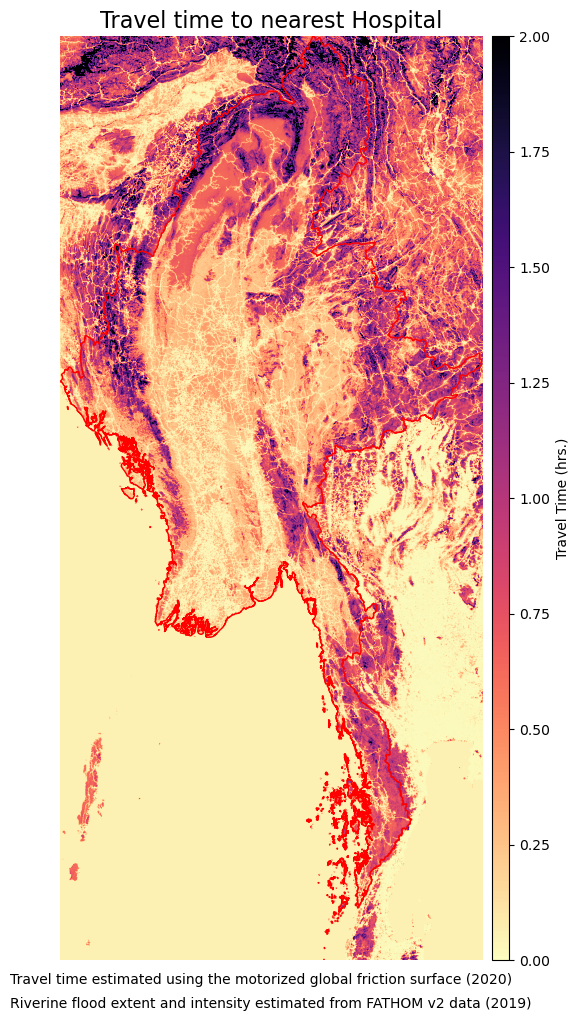

In [180]:
# Single Scenario Plot

figsize = (7, 12)
fig, ax = plt.subplots(1, 1,  figsize = figsize)
ax.set_title("Travel time to nearest Hospital", fontsize=16, horizontalalignment='center')
plt.axis('off')
ext = plotting_extent(tt_rio_hosp["conflict"])
adm0.plot(ax=ax, facecolor="none", edgecolor='red')
im = ax.imshow(travel_surf_conflict - travel_surf.read(1), vmin=0, vmax=2, cmap='magma_r', extent=ext)
# geodf_hf_hosp.plot(ax=ax, facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("Travel Time (hrs.)")
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs='EPSG:4326', zorder=-1)
txt= "Travel time estimated using the motorized global friction surface (2020)"
txt2 = "Riverine flood extent and intensity estimated from FATHOM v2 data (2019)"
plt.figtext(0.12, 0.09, txt, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.12, 0.07, txt2, wrap=True, horizontalalignment='left', fontsize=10)
# plt.savefig("travel-time-friction_flood100.png", dpi=300, bbox_inches='tight', facecolor='white')

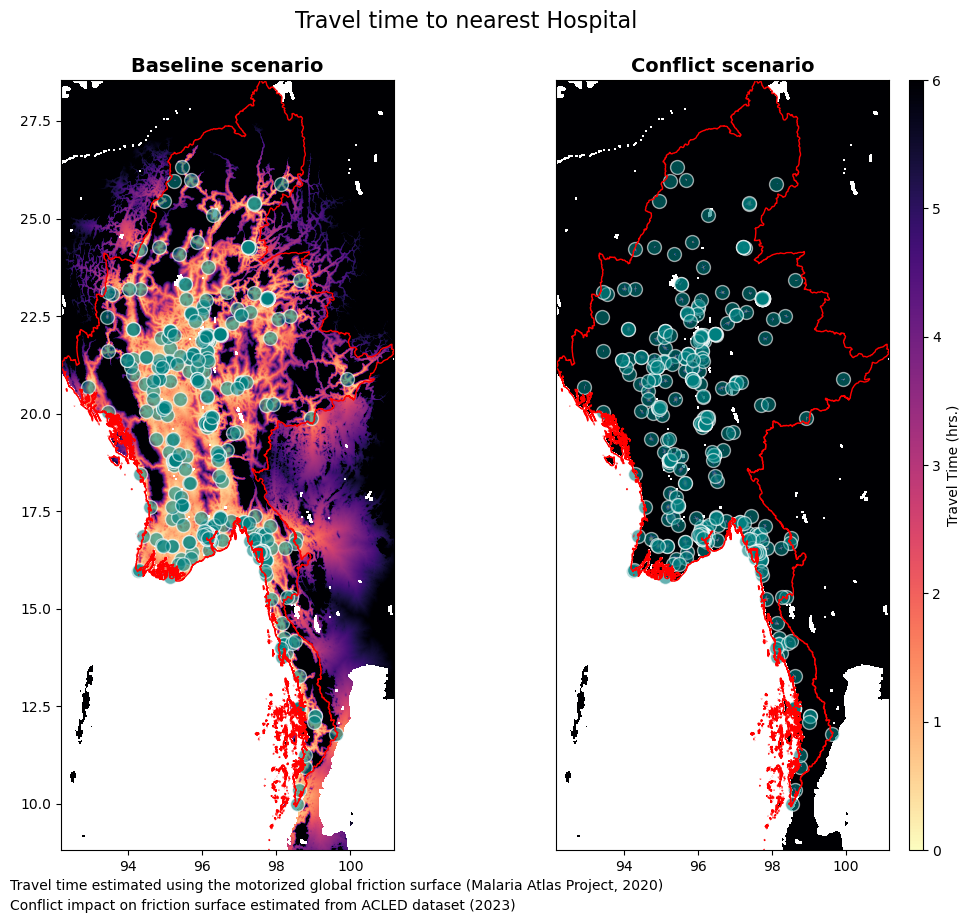

In [181]:
# Multiple Scenario plot

figsize = (12,10)
fig, ax = plt.subplots(1, 2,  figsize = figsize)

title = "Travel time to nearest Hospital"
fonttitle = {'weight':'bold','size':14}
fig.suptitle(title, size = 16, y = 0.95)
ax[0].set_title("Baseline scenario", fontdict=fonttitle)
ax[0].get_xaxis().set_visible(True) # plt.axis('off')
ax[0].get_yaxis().set_visible(True)

ax[1].set_title("Conflict scenario", fontdict=fonttitle)
ax[1].get_xaxis().set_visible(True) # plt.axis('off')
ax[1].get_yaxis().set_visible(False)

ext = plotting_extent(tt_rio_hosp['baseline'])
im = ax[0].imshow(tt_rio_hosp['baseline'].read(1), vmin=0, vmax=6, cmap='magma_r', extent=ext)
geodf_hf_hosp.plot(ax=ax[0], facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
adm0.plot(ax=ax[0], facecolor="none", edgecolor='red')

ext = plotting_extent(tt_rio_hosp["conflict"])
im1 = ax[1].imshow(tt_rio_hosp["conflict"].read(1), vmin=0, vmax=6, cmap='magma_r', extent=ext)
geodf_hf_hosp.plot(ax=ax[1], facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
adm0.plot(ax=ax[1], facecolor="none", edgecolor='red')

divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im1, cax=cax, orientation='vertical')
cb.set_label("Travel Time (hrs.)")
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs='EPSG:4326', zorder=-1)
txt = "Travel time estimated using the motorized global friction surface (Malaria Atlas Project, 2020)"
txt2 = "Conflict impact on friction surface estimated from ACLED dataset (2023)"
plt.figtext(0.12, 0.07, txt, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.12, 0.05, txt2, wrap=True, horizontalalignment='left', fontsize=10)

plt.savefig(out_path+iso+"Travel time to nearest Hospital - scenario_Davis&Ojoloko.png", dpi=300, bbox_inches='tight', facecolor='white')

### Summarize population within 2 hours from Health Facilities

In [80]:
pop = pop_surf.read(1, masked=True)

df_pop = pd.DataFrame(zonal_stats(adm1, pop.filled(), affine=pop_surf.transform, stats='sum', nodata=pop_surf.nodata)).rename(columns={'sum':'pop'})
df_pop_hosp = df_pop.copy()

pop_120_hospital = dict()
df_pop_120_hospital = dict()
for key in tt_rio_hosp.keys():
    pop_120_hospital[key] = pop*(tt_rio_hosp[key].read(1)<=2)
    df_pop_120_hospital[key] = pd.DataFrame(zonal_stats(adm1, pop_120_hospital[key].filled(), affine=pop_surf.transform, stats='sum', nodata=pop_surf.nodata)).rename(columns={'sum':'pop_120_hosp_'+key})
    df_pop_hosp = df_pop_hosp.join(df_pop_120_hospital[key])
    df_pop_hosp.loc[:, "hosp_pct_"+key] = df_pop_hosp.loc[:, "pop_120_hosp_"+key]/df_pop_hosp.loc[:, "pop"]*100
    res = adm1.join(df_pop_hosp)

res.head(2)

,ID_0,COUNTRY,ID_1,ADM1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry,pop,pop_120_hosp_baseline,hosp_pct_baseline,pop_120_hosp_conflict,hosp_pct_conflict
0,MMR,Myanmar,MMR.1_1,Ayeyarwady,Irrawaddy|Ayeyarwaddy|Ayeyawady|Irawadi|Irraou...,,Yin,Division,,MM.AY,,"MULTIPOLYGON (((94.64847 16.25050, 94.64894 16...",5733594.0,5655369.0,98.635672,5500217.0,95.929656
1,MMR,Myanmar,MMR.2_1,Bago,Pégou|Pegu,,Yin,Division,,MM.BA,,"MULTIPOLYGON (((96.90305 16.80917, 96.90361 16...",4636746.5,4420933.5,95.345594,4361849.5,94.071339


In [81]:
print(f"Summary of % of pop. within 2 hr. of hospital \n {res.hosp_pct_baseline.describe()}")
print(f"Summary of % of pop. within 2 hr. of hospital given conflicts condition \n {res.hosp_pct_conflict.describe()}")


Summary of % of pop. within 2 hr. of hospital 
 count     15.000000
mean      79.493607
std       21.003648
min       39.411014
25%       65.766021
50%       79.109817
75%       97.775254
max      100.000000
Name: hosp_pct_baseline, dtype: float64
Summary of % of pop. within 2 hr. of hospital given conflicts condition 
 count     15.000000
mean      75.997466
std       23.648102
min       33.269125
25%       60.738094
50%       76.032150
75%       96.191635
max      100.000000
Name: hosp_pct_conflict, dtype: float64


### Accessibility Maps (Share of pop.)

Percentage of population within 2 hours of driving to the nearest primary care facility, by District (ADM1).​

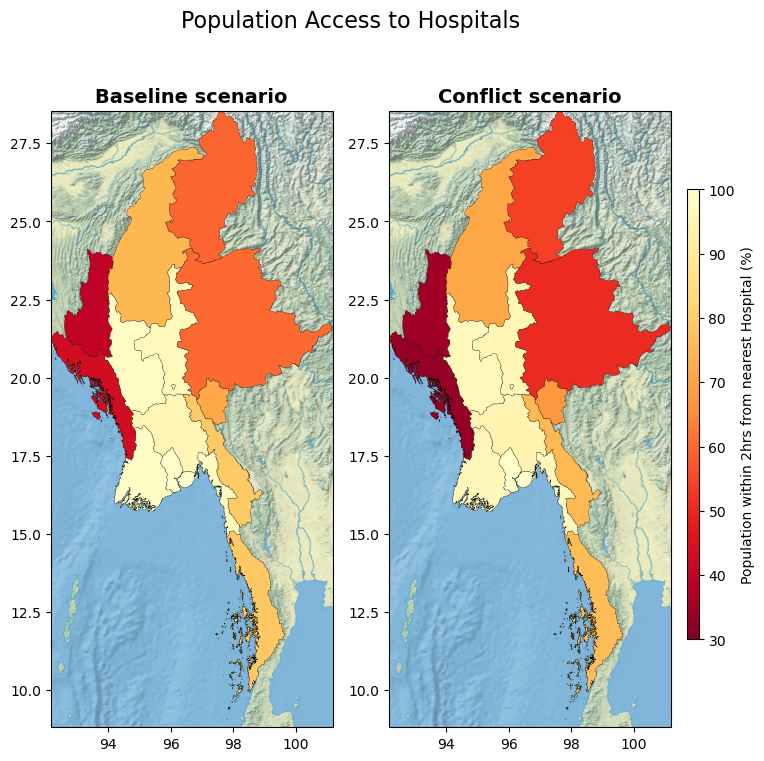

In [92]:
figsize = (8,9)
fig = plt.figure(figsize=figsize)
ax1 = fig.add_subplot(1, 2, 1, projection=projection)
ax2 = fig.add_subplot(1, 2, 2, projection=projection, sharex=ax1, sharey=ax1)

fonttitle = {'weight':'bold','size':14}

fig.suptitle("Population Access to Hospitals", size = 16, y = 0.95)
ax1.set_title("Baseline scenario", fontdict=fonttitle)
ax1.get_xaxis().set_visible(True) # plt.axis('off')
ax1.get_yaxis().set_visible(True)

ax2.set_title("Conflict scenario", fontdict=fonttitle)
ax2.get_xaxis().set_visible(True) # plt.axis('off')
ax2.get_yaxis().set_visible(True)

# Define the colormap
cmap = plt.get_cmap('YlOrRd_r')
# Define the normalization 
norm = colors.Normalize(vmin=30, vmax=100)

res.plot(
    ax=ax1, column='hosp_pct_baseline', cmap='YlOrRd_r', legend=False,
    alpha=1, linewidth=0.2, edgecolor='black',
    norm = norm
)

res.plot(
    ax=ax2, column='hosp_pct_conflict', cmap='YlOrRd_r', legend=False,
    alpha=1, linewidth=0.2, edgecolor='black',
    norm = norm
)

ax1.background_img(name='NaturalEarthRelief', resolution='high', extent = [adm0.bounds.minx[0], adm0.bounds.maxx[0], adm0.bounds.miny[0], adm0.bounds.maxy[0]])
ax2.background_img(name='NaturalEarthRelief', resolution='high', extent = [adm0.bounds.minx[0], adm0.bounds.maxx[0], adm0.bounds.miny[0], adm0.bounds.maxy[0]])

cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # Adjust the position and size of the colorbar here
sm = plt.cm.ScalarMappable(cmap=cmap, norm = norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Population within 2hrs from nearest Hospital (%)")

plt.savefig(join(out_path, iso, title+ ".png"), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

### Access to health disaggregated by wealth quintile

Categorize population grid by wealth quintiles, and then summarize the population with access to health (within 2 hours of health facility or hospital)

Hospitals

In [288]:
# Open Relative Wealth index and Population from Facebook
df_fb_rwi = pd.read_csv(os.path.join(data_dir, iso, 'meta', f'{iso.lower()}_relative_wealth_index.csv'))
geodf_fb = [Point(xy) for xy in zip(df_fb_rwi.longitude, df_fb_rwi.latitude)]
geodf_fb = gpd.GeoDataFrame(df_fb_rwi, crs=epsg, geometry=geodf_fb)
geodf_fb = gpd.sjoin(geodf_fb, adm1[['ADM1','geometry']])

df_fb_pop = pd.read_csv(os.path.join(data_dir, iso, 'meta', f'{iso.lower()}_general_2020.csv'))
df_fb_pop = df_fb_pop.rename(columns={f'{iso.lower()}_general_2020': 'pop_2020'})
    
df_fb_flood_hosp = dict()
for key in tt_rio_hosp.keys():

    # Zonal mean of RWI in tt_rio_hosp cells
    df_fb_flood_hosp[key] = pd.DataFrame(zonal_stats(geodf_fb, tt_rio_hosp[key].read(1, masked = True).filled(), affine=tt_rio_hosp[key].transform, stats='mean', nodata=tt_rio_hosp[key].nodata)).rename(columns={'mean':'tt_hospital_'+key})
    geodf_fb = geodf_fb.join(df_fb_flood_hosp[key])

    # Discretize in quantiles
    geodf_fb.loc[:, "rwi_cut_"+key] = pd.qcut(geodf_fb['rwi'], [0, .2, .4, .6, .8, 1.], labels=['lowest', 'second-lowest', 'middle', 'second-highest', 'highest'])
    
    # Merge RWI and population by matching the grid (quadkey)
    df_fb_pop['quadkey'+key] = df_fb_pop.apply(lambda x: str(quadkey.from_geo((x['latitude'], x['longitude']), 14)), axis=1)
    geodf_fb['quadkey'+key] = geodf_fb.apply(lambda x: str(quadkey.from_geo((x['latitude'], x['longitude']), 14)), axis=1)
    bing_tile_z14_pop = df_fb_pop.groupby('quadkey'+key, as_index=False)['pop_2020'].sum()

    rwi = geodf_fb.merge(bing_tile_z14_pop[['quadkey'+key, 'pop_2020']], on='quadkey'+key, how='inner')

res_rwi_adm0 = pd.DataFrame()
res_rwi_adm1 = pd.DataFrame()
for key in tt_rio_hosp.keys():

    # Define boolean proximity within 2hrs from hospital
    rwi.loc[:,"tt_hospital_bool_" + key] = rwi['tt_hospital_'+key]<=2
    
    # Aggregate at country level (ADM0)
    pop_adm0 = rwi[['rwi_cut_'+key, 'pop_2020']].groupby(['rwi_cut_'+key]).sum()
    hosp_adm0 = rwi.loc[rwi["tt_hospital_bool_" + key]==True, ['rwi_cut_'+key, 'pop_2020']].groupby(['rwi_cut_'+key]).sum().rename(columns={'pop_2020':'pop_120_hospital_'+key})
    rwi_adm0 = pop_adm0.join(hosp_adm0)
    res_rwi_adm0.loc[:, "hospital_pct_"+key] = rwi_adm0['pop_120_hospital_'+key]/rwi_adm0['pop_2020']

    # Aggregate at region level (ADM1)
    pop_adm1 = rwi[['ADM1','rwi_cut_'+key, 'pop_2020']].groupby(['ADM1','rwi_cut_'+key]).sum()
    hosp_adm1 = rwi.loc[rwi["tt_hospital_bool_" + key]==True, ['ADM1','rwi_cut_'+key, 'pop_2020']].groupby(['ADM1','rwi_cut_'+key]).sum().rename(columns={'pop_2020':'pop_120_hospital_'+key})
    rwi_adm1 = pop_adm1.join(hosp_adm1)
    res_rwi_adm1.loc[:, "hospital_pct_"+key] = rwi_adm1['pop_120_hospital_'+key]/rwi_adm1['pop_2020']

res_rwi_adm0.reset_index(inplace = True)
res_rwi_adm0 = res_rwi_adm0.rename(columns={'rwi_cut_1in5':'quantiles'})

res_rwi_adm1.reset_index(inplace = True)
res_rwi_adm1 = res_rwi_adm1.rename(columns={'rwi_cut_1in5':'quantiles'})


In [324]:
def sort_flood_col(gdf, str_start, str_sep):
    # Define str_start and str_sep as the strings that identify the start of column names and the separator with the numerical value
    fd_columns = [col for col in gdf.columns if str_start in col]
    non_fd_columns = [col for col in gdf.columns if not str_start in col]
    fd_num = [(int(col.split(str_sep)[1]), col) for col in fd_columns]
    fd_col_sort = [col for _, col in sorted(fd_num)]
    new_column_order = non_fd_columns + fd_col_sort
    # Reorder the DataFrame columns
    gdf = gdf[new_column_order]
    return(gdf)

In [329]:
# Melting for seaborn plot
res_rwi_adm0 = sort_flood_col(res_rwi_adm0, "1in", "in")
res_rwi_adm0_long = pd.melt(res_rwi_adm0, id_vars="quantiles", var_name="scen")
res_rwi_adm0_long.value = res_rwi_adm0_long.value*100
scen = res_rwi_adm0_long.scen.unique()
scen = [s.split("_")[2] for s in scen]

res_rwi_adm1 = sort_flood_col(res_rwi_adm1, "1in", "in")
res_rwi_adm1_long = pd.melt(res_rwi_adm1, id_vars=["ADM1","quantiles"], var_name="scen")
res_rwi_adm1_long.value = res_rwi_adm1_long.value*100

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


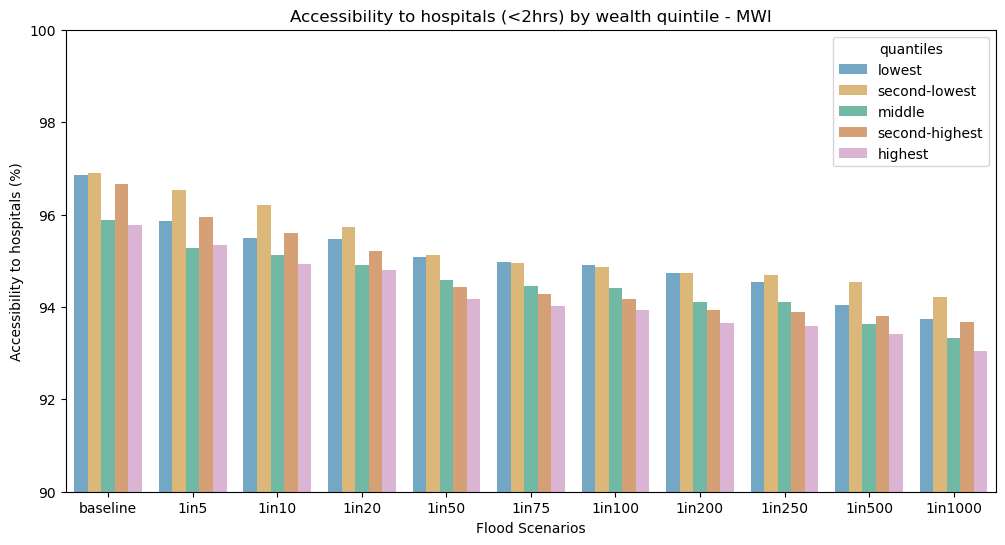

In [357]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Accessibility to hospitals (<2hrs) by wealth quintile - " + iso)
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios")
ax0.set_ylabel("Accessibility to hospitals (%)")
ax0.set_ylim(90,100)
ax0.legend(loc='upper left', fontsize = 10, title = "RWI quantiles")
ax0 = sns.barplot(
    data=res_rwi_adm0_long, hue="quantiles",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)

In [500]:
res_rwi_adm1["hospital_pct_impact"] = (res_rwi_adm1["hospital_pct_1in1000"] - res_rwi_adm1["hospital_pct_baseline"])/res_rwi_adm1["hospital_pct_baseline"]

In [501]:
test = res_rwi_adm1.copy()
test = test[["ADM1", "quantiles", "hospital_pct_impact"]]

quant = pd.DataFrame(test["ADM1"].unique())
for q in test.quantiles.unique().to_list():
    quant["hospital_pct_impact_"+ q] = test[test["quantiles"] == q]["hospital_pct_impact"].values.round(3)*100
    
quant = quant.rename(columns = {quant.columns[0]:"ADM1"})
quant = quant.merge(right = adm1[["ADM1",'geometry']], on = "ADM1", how = "left")
quant = gpd.GeoDataFrame(quant, crs=epsg, geometry="geometry")
# quant = quant*100
quant.head(2)

,ADM1,hospital_pct_impact_lowest,hospital_pct_impact_second-lowest,hospital_pct_impact_middle,hospital_pct_impact_second-highest,hospital_pct_impact_highest,geometry
0,Balaka,0.0,-0.5,-2.1,-2.0,-1.5,"MULTIPOLYGON (((35.07923 -15.30382, 35.07925 -..."
1,Blantyre,-5.5,-2.1,0.0,-6.6,-2.1,"MULTIPOLYGON (((34.94884 -15.98430, 34.94793 -..."


In [6]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 6)

fig.suptitle("Sensitivity of Hospitals Accessibility (<2hrs) by wealth quintile (ADM1)", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

for i, q in enumerate(quant.columns[1:6]):
    if i < 3:
        ax = fig.add_subplot(gs[0, 2 * i : 2 * i + 2], projection=projection)
    else:
        ax = fig.add_subplot(gs[1, 2 * i - 5 : 2 * i - 3], projection=projection)

    ax.set_title(q.split("_")[3])
    ax.get_xaxis().set_visible(True) # plt.axis('off')
    ax.get_yaxis().set_visible(True)
    
    cmap = "RdYlGn"

    if i == 4:
        quant.plot(
        ax=ax, column=q, cmap=cmap, legend=True,
        alpha=1, linewidth=0.2, edgecolor='black', 
        # scheme = "user defined", classification_kwds = {'bins': [-0.02,-0.04,-0.6,-0.08,-0.10,-0.12]},
        legend_kwds = {
            'label': "Reduction of within 2km \n Hospitals accessibility (%)",
            # "loc": "upper right",
            # "bbox_to_anchor": (2.7, 1), 
            # 'fontsize': 10,
            # 'fmt': "{:.0%}",
            # 'title_fontsize': 12
        }
    )
    else:
        quant.plot(
        ax=ax, column=q, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        # scheme = "naturalbreaks", classification_kwds = {'bins': [-0.02,-0.04,-0.6,-0.08,-0.10,-0.12]},
        legend_kwds = {
            'title': "Reduction of within 2km \n Hospitals accessibility (%)",
            "loc": "upper right",
            "bbox_to_anchor": (2.7, 1), 
            'fontsize': 10,
            'fmt': "{:.0%}",
            'title_fontsize': 12
        }
    )
        
    # ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

In [3]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Accessibility to hospitals (<2hrs) by wealth quintile")
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios")
ax0.set_ylabel("Accessibility to hospitals (%)")
ax0.set_ylim(90,100)
ax0.legend(loc='upper left', fontsize = 10, title = "RWI quantiles")
ax0 = sns.barplot(
    data=res_rwi_adm1_long, hue="quantiles",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)